# Question A2 (10 marks)

### In this question, we will determine the optimal learning rate for mini-batch gradient descent. Find the optimal learning rate for mini-batch gradient descent by training the neural network and evaluating the performances for different learning rates. Note: Use 5-fold cross-validation on the training partition to perform hyperparameter selection. You will have to reconsider the scaling of the dataset during the 5-fold cross validation.

#### Plot mean cross-validation accuracies on the final epoch for different learning rates as a scatter plot. Limit search space to learning rates {0.001, 0.005, 0.0001, 0.0005}. Next, create a table of number of epochs required to reach convergence against different learning rates. Finally, select the optimal learning rate and state a reason for your selection.



This might take a while to run, so plan your time carefully.

In [4]:
import tqdm
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from scipy.io import wavfile as wav

from sklearn import preprocessing
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix

from common_utils import set_seed
from common_utils import split_dataset, preprocess_dataset
from common_utils import MLP, loss_fn, CustomDataset, EarlyStopper
from common_utils import train_loop, test_loop

#### 1.To reduce repeated code, place your

- network (MLP defined in QA1)

- torch datasets (CustomDataset defined in QA1)
- loss function (loss_fn defined in QA1)
in a separate file called common_utils.py

Import them into this file. You will not be repenalised for any error in QA1 here as the code in QA1 will not be remarked.

The following code cell will not be marked.

In [6]:
no_labels = 1
no_features = 77
hidden_layers = [128, 128, 128]

dropout_rate = 0.3

no_of_epochs = 200

weight_decay = 0.0005
early_stopping_patience = 5
batch_size = 64

seed = 69
no_of_folds = 5

set_seed(seed)

In [7]:
def preprocess(df):
    x_train, y_train, x_test, y_test = split_dataset(df = df, columns_to_drop = ['filename', 'label'], test_size = 0.25, random_state = seed)
    
    return x_train, y_train, x_test, y_test

df = pd.read_csv('simplified.csv')
df['label'] = df['filename'].str.split('_').str[-2]

X_train, y_train, X_test, y_test = preprocess(df)

#### 2. Define different folds for different learning rates to get a dictionary of training and validation datasets. Preprocess your datasets accordingly.

In [9]:
def generate_cv_folds_for_learning_rates(parameters, X_train, y_train):
    """
    returns:
    X_train_scaled_dict(dict) where X_train_scaled_dict[learning_rate] is a list of the preprocessed training matrix for the different folds.
    X_val_scaled_dict(dict) where X_val_scaled_dict[learning_rate] is a list of the processed validation matrix for the different folds.
    y_train_dict(dict) where y_train_dict[learning_rate] is a list of labels for the different folds
    y_val_dict(dict) where y_val_dict[learning_rate] is a list of labels for the different folds
    """
    kf = KFold(n_splits = no_of_folds, shuffle = True, random_state = seed)

    # initialise empty dicts for each learning rate
    X_train_scaled_dict = {lr: [] for lr in parameters}
    X_val_scaled_dict   = {lr: [] for lr in parameters}
    y_train_dict        = {lr: [] for lr in parameters}
    y_val_dict          = {lr: [] for lr in parameters}

    
    for train_idx, val_idx in kf.split(X_train):
        # split fold
        X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
        y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]

        # fit scaler on fold train only, transform val
        X_fold_train_scaled, X_fold_val_scaled = preprocess_dataset(X_fold_train, X_fold_val)

        # same folds for all learning rates
        for lr in parameters:
            X_train_scaled_dict[lr].append(X_fold_train_scaled)
            X_val_scaled_dict[lr].append(X_fold_val_scaled)
            y_train_dict[lr].append(y_fold_train)
            y_val_dict[lr].append(y_fold_val)
    
    return X_train_scaled_dict, X_val_scaled_dict, y_train_dict, y_val_dict

In [10]:
learning_rates = [0.001, 0.005, 0.0001, 0.0005]
X_train_scaled_dict, X_val_scaled_dict, y_train_dict, y_val_dict = generate_cv_folds_for_learning_rates(learning_rates, X_train.to_numpy(), y_train)

#### 3.Perform hyperparameter tuning for the different learning rates with 5-fold cross validation.

In [12]:
def find_optimal_hyperparameter(X_train_scaled_dict, X_val_scaled_dict, y_train_dict, y_val_dict, learning_rates, parameter):

    cross_validation_accuracies = {}  # avg val accuracy per lr
    cross_validation_times      = {}  # avg epochs per lr

    for lr in learning_rates:
        fold_val_accuracies = []
        fold_epochs         = []

        for fold in range(5):
            #Data
            train_data   = CustomDataset(X_train_scaled_dict[lr][fold], y_train_dict[lr][fold])
            val_data     = CustomDataset(X_val_scaled_dict[lr][fold],   y_val_dict[lr][fold])
            train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
            val_loader   = DataLoader(val_data,   batch_size=batch_size, shuffle=False)

            #Model
            set_seed(seed)
            device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
            model         = MLP(no_features=no_features, hidden_layers=hidden_layers, no_labels=no_labels, dropout_rate=dropout_rate).to(device)
            optimizer     = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
            early_stopper = EarlyStopper(patience=early_stopping_patience, min_delta=0)

            #Training
            epoch_count = 0

            for t in range(no_of_epochs):
                epoch_count += 1
                train_loop(train_loader, model, loss_fn, optimizer)
                val_loss, val_acc = test_loop(val_loader, model, loss_fn)

                if early_stopper.early_stop(val_loss):
                    break

            fold_val_accuracies.append(val_acc)
            fold_epochs.append(epoch_count)

            print(f"  [{parameter}={lr}] Fold {fold+1} | Val Accuracy: {val_acc:.4f} | Epochs: {epoch_count}")

        #Average across 5 folds
        avg_acc    = sum(fold_val_accuracies) / len(fold_val_accuracies)
        avg_epochs = sum(fold_epochs)         / len(fold_epochs)

        cross_validation_accuracies[lr] = avg_acc
        cross_validation_times[lr]      = avg_epochs

        print(f"\n[{parameter}={lr}] Avg Val Accuracy: {avg_acc:.4f} | Avg Epochs: {avg_epochs:.1f}\n")

    return cross_validation_accuracies, cross_validation_times

In [13]:
learning_rates = [0.001, 0.005, 0.0001, 0.0005]
cross_validation_accuracies, cross_validation_times = find_optimal_hyperparameter(X_train_scaled_dict, X_val_scaled_dict, y_train_dict, y_val_dict, learning_rates, 'learning_rate')

  [learning_rate=0.001] Fold 1 | Val Accuracy: 0.6285 | Epochs: 12
  [learning_rate=0.001] Fold 2 | Val Accuracy: 0.6938 | Epochs: 46
  [learning_rate=0.001] Fold 3 | Val Accuracy: 0.6753 | Epochs: 26
  [learning_rate=0.001] Fold 4 | Val Accuracy: 0.6648 | Epochs: 20
  [learning_rate=0.001] Fold 5 | Val Accuracy: 0.6947 | Epochs: 35

[learning_rate=0.001] Avg Val Accuracy: 0.6714 | Avg Epochs: 27.8

  [learning_rate=0.005] Fold 1 | Val Accuracy: 0.6296 | Epochs: 24
  [learning_rate=0.005] Fold 2 | Val Accuracy: 0.6075 | Epochs: 21
  [learning_rate=0.005] Fold 3 | Val Accuracy: 0.6084 | Epochs: 19
  [learning_rate=0.005] Fold 4 | Val Accuracy: 0.5996 | Epochs: 10
  [learning_rate=0.005] Fold 5 | Val Accuracy: 0.6156 | Epochs: 21

[learning_rate=0.005] Avg Val Accuracy: 0.6121 | Avg Epochs: 19.0

  [learning_rate=0.0001] Fold 1 | Val Accuracy: 0.6048 | Epochs: 41
  [learning_rate=0.0001] Fold 2 | Val Accuracy: 0.6025 | Epochs: 24
  [learning_rate=0.0001] Fold 3 | Val Accuracy: 0.6189 | E

#### 4. Plot scatterplot of mean cross validation accuracies for the different learning rates.

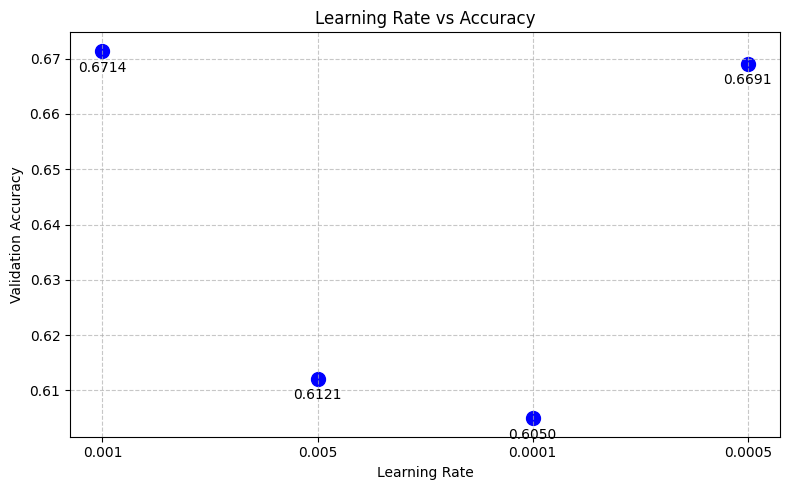

In [15]:
lr_labels = [str(lr) for lr in cross_validation_accuracies.keys()]
accs      = list(cross_validation_accuracies.values())
x_pos     = range(len(lr_labels))

plt.figure(figsize=(8, 5))
plt.scatter(x_pos, accs, color='blue', s=100)

# annotate INSIDE the graph (below the dot)
for i in range(len(lr_labels)):
    plt.annotate(f'{accs[i]:.4f}', (x_pos[i], accs[i]), 
                 textcoords="offset points", 
                 xytext=(0, -15),        # ← negative moves label below dot
                 ha='center')           # ← center align

plt.xticks(x_pos, lr_labels)
plt.xlabel('Learning Rate')
plt.ylabel('Validation Accuracy')
plt.title('Learning Rate vs Accuracy')
plt.grid(True, linestyle='--', alpha=0.7)   # ← grid lines
plt.tight_layout()
plt.show()

#### 4. Create a table of number of epochs required to reach convergence against different learning rates. Select the optimal learning rate and state a reason for your selection.

In [17]:
df = pd.DataFrame({
    'Learning Rate'             : list(cross_validation_times.keys()),
    'Number of Epochs Required' : list(cross_validation_times.values()),
    'Validation Accuracy'       : list(cross_validation_accuracies.values())
})

df['Learning Rate']             = df['Learning Rate'].astype(str)
df['Number of Epochs Required'] = df['Number of Epochs Required'].round(1)
df['Validation Accuracy']       = df['Validation Accuracy'].round(4)

df

,Learning Rate,Number of Epochs Required,Validation Accuracy
0,0.001,27.8,0.6714
1,0.005,19.0,0.6121
2,0.0001,29.2,0.6050
3,0.0005,26.6,0.6691


In [18]:
optimal_learning_rate = max(cross_validation_accuracies, key=cross_validation_accuracies.get)

answer = answer = f'''The optimal learning rate selected is {optimal_learning_rate}.

It achieves the highest validation accuracy of {cross_validation_accuracies[optimal_learning_rate]:.4f} across 5-fold cross validation, with an average of {cross_validation_times[optimal_learning_rate]:.1f} epochs to converge.

Although learning rate 0.0005 achieves a similar accuracy of {cross_validation_accuracies[0.0005]:.4f}, learning rate 0.001 converges faster with fewer epochs ({cross_validation_times[0.001]:.1f} vs {cross_validation_times[0.0005]:.1f}), making it more computationally efficient without sacrificing accuracy.

Learning rates 0.005 and 0.0001 are rejected as they produce noticeably lower validation accuracies of {cross_validation_accuracies[0.005]:.4f} and {cross_validation_accuracies[0.0001]:.4f} respectively. A learning rate of 0.005 is too large, causing the model to overshoot the minimum, while 0.0001 is too small, resulting in slow and incomplete convergence within the given epochs.

Therefore, {optimal_learning_rate} strikes the best balance between accuracy and convergence speed.'''

print(answer)

The optimal learning rate selected is 0.001.

It achieves the highest validation accuracy of 0.6714 across 5-fold cross validation, with an average of 27.8 epochs to converge.

Although learning rate 0.0005 achieves a similar accuracy of 0.6691, learning rate 0.001 converges faster with fewer epochs (27.8 vs 26.6), making it more computationally efficient without sacrificing accuracy.

Learning rates 0.005 and 0.0001 are rejected as they produce noticeably lower validation accuracies of 0.6121 and 0.6050 respectively. A learning rate of 0.005 is too large, causing the model to overshoot the minimum, while 0.0001 is too small, resulting in slow and incomplete convergence within the given epochs.

Therefore, 0.001 strikes the best balance between accuracy and convergence speed.
